In [7]:
from pathlib import Path
import sys

import pandas as pd
root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from weather_stylist.ml.synthetic_dataset import generate_synthetic_dataset
from weather_stylist.ml.train_model import main as train_warmth_model
from weather_stylist.ml.features import FEATURE_COLUMNS
from weather_stylist.ml.model_loader import get_regressor
from weather_stylist.adapters.user_bd. import engine as sync_engine, FeedbackORM, UserORM


ml_dir = root / "weather_stylist" / "ml"
data_dir = ml_dir / "data"
csv_path = data_dir / "synthetic_feedback.csv"
csv_path

PosixPath('/mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/ml/data/synthetic_feedback.csv')

## Модель комфортного индекса теплоты 

### Синтетический датасет

Сгенерируем синтетический датасет. В synthetic_dataset.generate_synthetic_dataset по умолчанию 5000 примеров


In [8]:
generate_synthetic_dataset(n_samples=5000)

synthetic dataset saved to /mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/ml/data/synthetic_feedback.csv


Пример синтетических данных

In [9]:
df = pd.read_csv(csv_path)  # первые 5 строк
df.head()


,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,required_warmth
0,9,17,8.637544,0,1,0.0,2.0
1,1,8,14.962375,0,1,0.0,5.0
2,23,32,6.411324,0,1,0.0,0.0
3,-14,-10,7.185626,1,1,0.0,13.0
4,-2,4,13.235409,1,1,0.0,6.0


Средняя информация по всем объектам:

In [10]:
df.describe(include="all")

,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,required_warmth
count,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.0,5000.00000
mean,2.390000,7.3700,7.540891,0.485200,0.003000,0.0,7.60240
std,16.310656,16.0801,4.289260,0.499831,0.818001,0.0,5.85976
min,-30.000000,-20.0000,0.009222,0.000000,-1.000000,0.0,0.00000
25%,-12.000000,-6.0000,3.901630,0.000000,-1.000000,0.0,3.00000
50%,2.000000,7.0000,7.566997,0.000000,0.000000,0.0,6.00000
75%,16.000000,21.0000,11.174506,1.000000,1.000000,0.0,13.00000
max,35.000000,35.0000,14.998316,1.000000,1.000000,0.0,21.00000


### Обучение модели

Запускаем обучвение модели. Вызываем train_madel.py, который читает датасет, там происходит деление на train/test, считаются метрики, модель сохраняется

In [11]:
train_warmth_model()

MAE: 0.1662613745514793
R^2: 0.9984645539523397
model saved to /mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/ml/comfort_regressor.pkl


В качестве модели используется RandomForestRegressor из библиотеки scikit-learn с 200 деревьями (n_estimators=200) и ограничением глубины деревьев (max_depth=8), что позволяет моделировать нелинейную зависимость между погодой, профилем пользователя и требуемой «теплотой» комплекта, но при этом ограничивать переобучение.

In [12]:
reg = get_regressor()
reg

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [13]:
sample = df.iloc[0]

X_sample = sample[FEATURE_COLUMNS].values.reshape(1, -1)
y_true = sample["required_warmth"]
y_pred = reg.predict(X_sample)[0]

print("y_true:", y_true)
print("y_pred:", y_pred)


y_true: 2.0
y_pred: 2.2196963969488612


/mnt/d/hw/python_adv/final-project-adv-python/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


MAE on test: 0.166
R^2 on test: 0.998


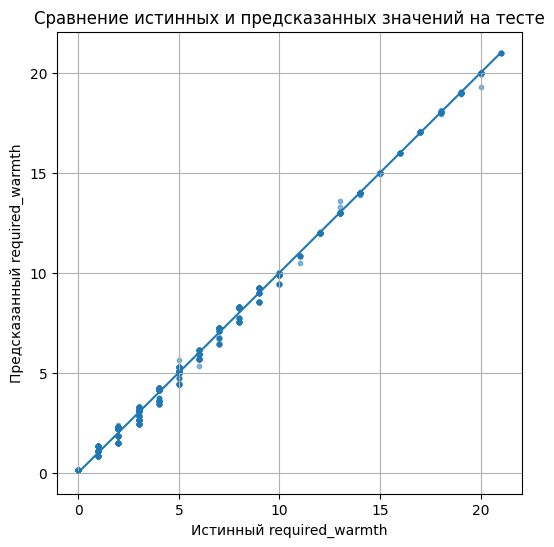

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X = df[FEATURE_COLUMNS]
y = df["required_warmth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE on test: {mae:.3f}")
print(f"R^2 on test: {r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Истинный required_warmth")
plt.ylabel("Предсказанный required_warmth")
plt.title("Сравнение истинных и предсказанных значений на тесте")
plt.grid(True)
plt.show()


### Покажем на примере свзяь с ботом

Соберём искусственный прогноз погоды на день

In [15]:
from weather_stylist.models.weather import DayForecast
from weather_stylist.models.user import User
from weather_stylist.ml.features import make_features

# пример прогноза на день
fake_forecast = DayForecast(
    city="Prague",
    min_temp=3.0,
    max_temp=9.0,
    wind_max=5.0,
    will_rain=True, 
    hourly=[]
)

# пример пользователя
fake_user = User(
    tg_id=123456,
    city="Prague",
    name="Test User",
    region="unknown",
    thermo_profile=0,  
    warmth_shift=0.0,
    feedback_count=0,
    cold_count=0,
    hot_count=0,
)

features_vec = make_features(fake_forecast, fake_user)
features_vec


[3.0, 9.0, 5.0, 1.0, 0.0, 0.0]

In [16]:
X = pd.DataFrame([features_vec], columns=FEATURE_COLUMNS)
reg.predict(X)[0]

np.float64(5.950080049034778)

По (forecast, user) с помощью `make_features` можно построить вектор признаков, тот же вектор корректно принимает регрессор из `comfort_regressor.pkl`

# Переход к реальным фидбекам

В начале проекта у нас не было пользовательских фидбеков, поэтому мы задали экспертные правила required_warmth_rule_based (температура + ветер + дождь + термопрофиль),
сгенерировали синтетический датасет synthetic_feedback.csv через synthetic_dataset.py,
обучили базовую модель comfort_regressor.pkl, которая аппроксимирует эти правила.
Благодаря этому бот адекватно работает даже при нулевых фидбеках.

После тестов и накопления 100+ записей в таблице feedback мы перещли ко второй стадии обучения.
Теперь мы не пытаемся заново предсказать весь target, а учим модель предсказывать небольшую поправку delta к базовому правилу.

- label = -1 (было холодно) $\Rightarrow$ delta = +K 
- label = 0 (ok) $\Rightarrow$ delta = 0 
- label = +1 (hot) $\Rightarrow$ delta = -K 

Синтетика при этом остаётся: для регресс-тестов, а сам бот опирается на новую тактику.

In [24]:
from pathlib import Path
import weather_stylist.adapters.user_bd.bd as bd

print("SYNC_DB_URL:", bd.SYNC_DB_URL)
print("DEFAULT_DB_PATH:", bd.DEFAULT_DB_PATH)

p = Path(bd.DEFAULT_DB_PATH)
print("exists:", p.exists(), "size:", p.stat().st_size, "bytes", "mtime:", p.stat().st_mtime)



SYNC_DB_URL: sqlite:////mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/adapters/user_bd/weather_stylist.db
DEFAULT_DB_PATH: /mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/adapters/user_bd/weather_stylist.db
exists: True size: 12288 bytes mtime: 1766578564.6675146


In [17]:
# Обучение delta-модели на реальных фидбеках из бд

import pandas as pd
from sqlalchemy import select

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import joblib



# читаем реальные фидбеки 
stmt = (
    select(
        FeedbackORM.temp_min,
        FeedbackORM.temp_max,
        FeedbackORM.wind_max,
        FeedbackORM.will_rain,
        FeedbackORM.thermo_profile,
        UserORM.warmth_shift,
        FeedbackORM.label,
    )
    .join(UserORM, UserORM.tg_id == FeedbackORM.user_tg_id)
)

df_real = pd.read_sql(stmt, sync_engine)
print("real feedback rows:", len(df_real))
df_real.head()

real feedback rows: 0


,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,label


In [19]:
#  строим таргет delta и обучаем модель
df_real["will_rain"] = df_real["will_rain"].astype(int)
K = 1.0
df_real["delta"] = (-df_real["label"].clip(-1, 1)) * K

X = df_real[FEATURE_COLUMNS]
y = df_real["delta"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Простая стабильная модель для малых данных
delta_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

delta_model.fit(X_train, y_train)

pred = delta_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))
print("R^2:", r2_score(y_test, pred))

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [18]:
# сохраняем delta-модель

from pathlib import Path

ml_dir = root / "weather_stylist" / "ml"
out_path = ml_dir / "comfort_delta_regressor.pkl"

joblib.dump(delta_model, out_path)
out_path


NameError: name 'delta_model' is not defined